# Assignment 1 – Dataset Analysis & Data Cleaning
**Dataset:** Titanic  
**Objective:** Understand dataset structures and perform data preprocessing.


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Dataset


In [ ]:
# Change this path to your titanic.csv file location
CSV_PATH = "titanic.csv"

df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded! Shape: {df.shape}")
df.head()


Dataset loaded! Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Explore Dataset

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData Types:")
print(df.dtypes)


Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
print("Missing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 4. Data Cleaning
### 4a. Handle Null Values


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop(columns=['Cabin'], inplace=True)

print("Null values handled!")
print("\nRemaining missing values:")
print(df.isnull().sum())


Null values handled!

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### 4b. Remove Duplicates

In [ ]:
print(f"Duplicate rows found: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after cleaning: {df.shape}")


Duplicate rows found: 0
Dataset shape after cleaning: (891, 11)


## 5. Basic Statistical Analysis

In [ ]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.36,0.52,0.38,32.20
std,257.35,0.49,0.84,13.02,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,22.00,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,35.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [ ]:
survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate : {survival_rate:.1f}%")

print("\nSurvival Rate by Gender:")
print((df.groupby('Sex')['Survived'].mean() * 100).round(1))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby('Pclass')['Survived'].mean() * 100).round(1))


Overall Survival Rate : 38.4%

Survival Rate by Gender:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


## 6. Visualizations

### Bar Chart – Survival Count by Gender

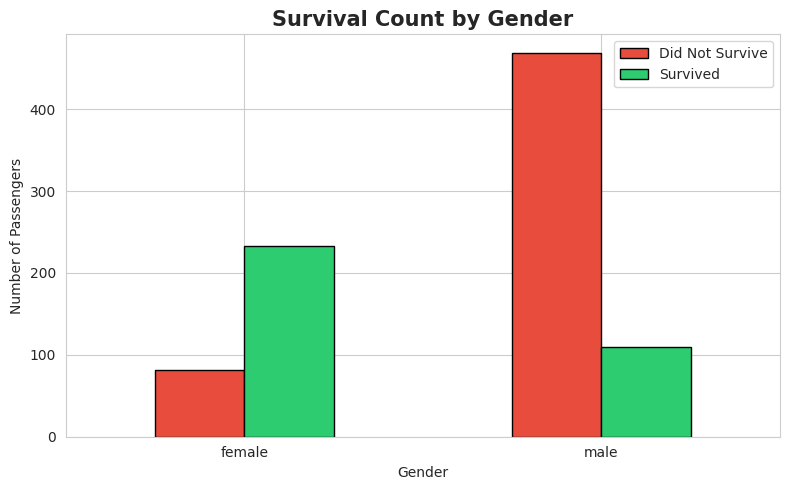

In [ ]:
gender_surv = df.groupby(['Sex', 'Survived']).size().unstack()
gender_surv.columns = ['Did Not Survive', 'Survived']

gender_surv.plot(kind='bar', color=['#E74C3C', '#2ECC71'], edgecolor='black', figsize=(8, 5))

plt.title('Survival Count by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150)
plt.show()


### Pie Chart – Passenger Class Distribution

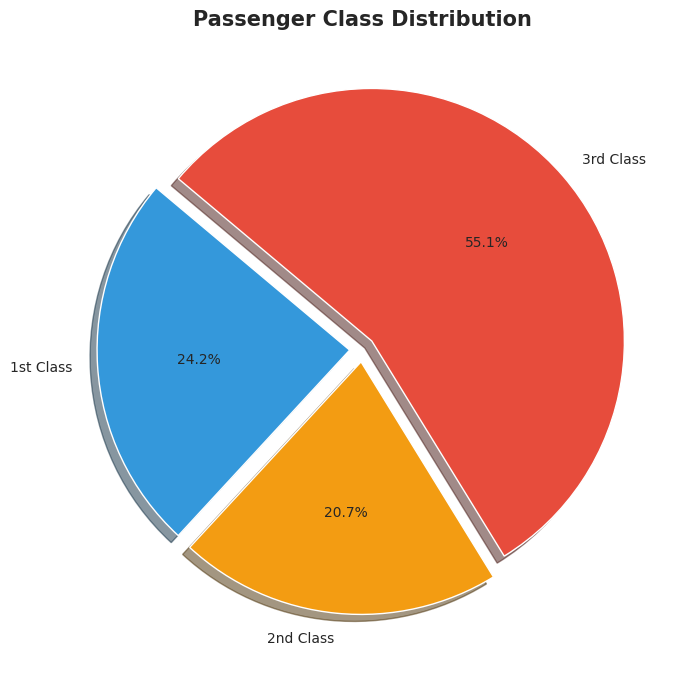

In [ ]:
class_counts = df['Pclass'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    class_counts,
    labels=['1st Class', '2nd Class', '3rd Class'],
    autopct='%1.1f%%',
    colors=['#3498DB', '#F39C12', '#E74C3C'],
    startangle=140,
    explode=(0.05, 0.05, 0.05),
    shadow=True
)
plt.title('Passenger Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_chart.png', dpi=150)
plt.show()


### Line Graph – Average Fare by Age Group

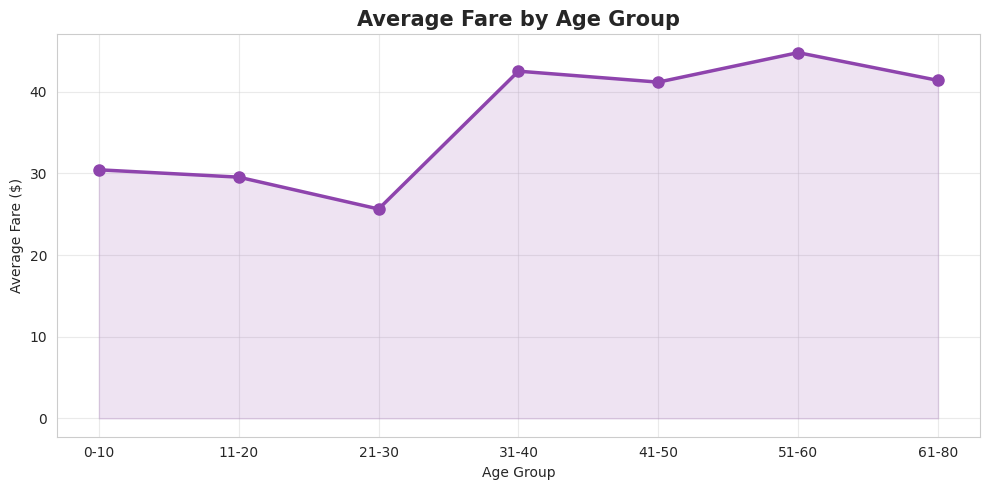

In [ ]:
df['Age Group'] = pd.cut(df['Age'],
                         bins=[0, 10, 20, 30, 40, 50, 60, 80],
                         labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-80'])

avg_fare = df.groupby('Age Group', observed=True)['Fare'].mean().round(2)

plt.figure(figsize=(10, 5))
plt.plot(avg_fare.index, avg_fare.values, marker='o', color='#8E44AD', linewidth=2.5, markersize=8)
plt.fill_between(range(len(avg_fare)), avg_fare.values, alpha=0.15, color='#8E44AD')

plt.title('Average Fare by Age Group', fontsize=15, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Fare ($)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('line_graph.png', dpi=150)
plt.show()
